<a href="https://colab.research.google.com/github/MAngelica-Sandoval/Proyecto-Analisis-de-Datos-NORM/blob/main/sesiones_practicas/sp_2_Maria_Sandoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis de datos Modaria II.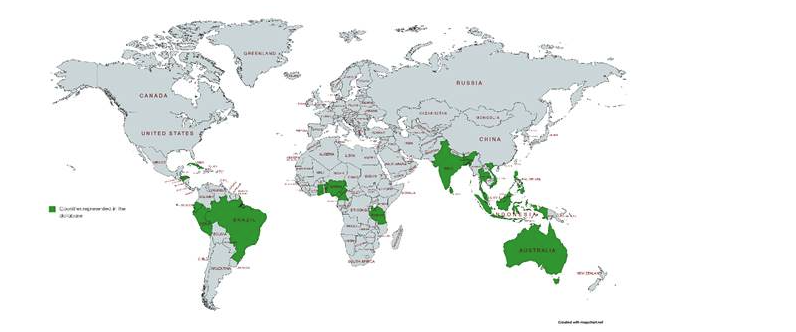

### <span style="color:#2F749F;"><strong>Parte 1. Analisis Univariado</strong></span>
### <span style="color:#2F749F;"><strong>Ejercicio 1: Cálculo de medidas de tendencia central</strong></span>


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Definir la URL del dataset de la IAEA
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'

# 2. Cargar el archivo directamente desde la red
try:
    df = pd.read_csv(url)
    print(f"Forma del dataset: {df.shape}") # Para ver cuántas filas y columnas tiene
except Exception as e:
    print(f"Hubo un error al cargar los datos: {e}")

# 3. Mostrar las primeras filas para confirmar
print(df.head())

Forma del dataset: (7151, 41)
   Record Element Radionuclide Common name         Latin name Compartment  \
0       1      Cr          NaN      Potato  Solanum tuberosum      Tubers   
1       2      Co          NaN      Potato  Solanum tuberosum      Tubers   
2       3      Ni          NaN      Potato  Solanum tuberosum      Tubers   
3       4      Cu          NaN      Potato  Solanum tuberosum      Tubers   
4       5      Pb          NaN      Potato  Solanum tuberosum      Tubers   

         CR  Uncert._CR  N_CR  Min_CR  ...  OM Exch. K  Exch. Ca  Exch. Mg  \
0  3.60E-02         NaN   NaN     NaN  ... NaN     NaN       NaN       NaN   
1  1.70E-02         NaN   NaN     NaN  ... NaN     NaN       NaN       NaN   
2  3.70E-02         NaN   NaN     NaN  ... NaN     NaN       NaN       NaN   
3  2.50E-01         NaN   NaN     NaN  ... NaN     NaN       NaN       NaN   
4  1.60E-02         NaN   NaN     NaN  ... NaN     NaN       NaN       NaN   

   CEC   pH  QC meas. QC sampl. QC equ

**Parte 1: Análisis Univariado**


Para este analisis univariado, escogí la variable de la concentración del suelo C_soil, en radioecologia el suelo es el reservorio inicial y principal para la bioacumulacion de contaminantes. Es impotante porque antes de entender como estos elemntos llegan a las plantas y a sus compartimientos es importante conocer los valores de la fuente de contaminacion en este caso el suelo.

--- Resultados de Tendencia Central ---
Media:   2338.4465
Mediana: 41.0000
Moda:    0.0500


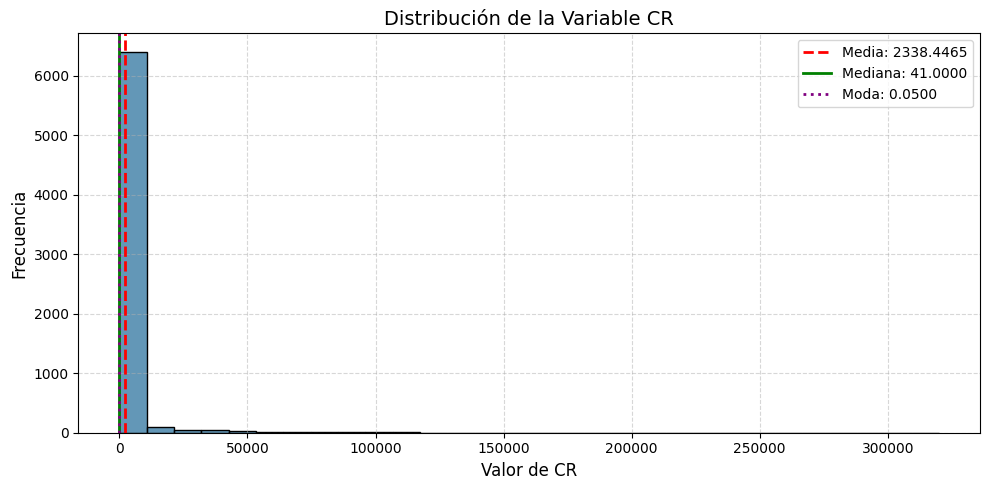

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Cargar el dataset
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Limpieza de la variable CR esto es Indispensable para evitar el TypeError
# Quitamos el símbolo '<' y convertimos a número ya que por los límites de deteccion se deja el numero
df['CR_limpia'] = df['C_soil'].astype(str).str.replace('<', '')# este replace es por limites de deteccion de los analsisis no es cero, si tiene un valor muy pequeno por eso se deja solo el valor muy pequeño
df['CR_limpia'] = pd.to_numeric(df['CR_limpia'], errors='coerce')

# Eliminamos valores nulos
cr_data = df['CR_limpia'].dropna()

# 3. Cálculo de medidas de tendencia central
media = np.mean(cr_data)
mediana = np.median(cr_data)
# Calculo la moda
moda_res = stats.mode(cr_data, keepdims=True)
moda = moda_res.mode[0]

# Imprimir resultados
print("--- Resultados de Tendencia Central ---")
print(f"Media:   {media:.4f}")
print(f"Mediana: {mediana:.4f}")
print(f"Moda:    {moda:.4f}")

# 4. Gráfico en Escala Lineal (Igual al ejemplo de los helados)
plt.figure(figsize=(10, 5))

# Histograma normal
sns.histplot(cr_data, bins=30, kde=False, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.4f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.4f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.4f}')

# Configuración visual
plt.title("Distribución de la Variable CR", fontsize=14)
plt.xlabel("Valor de CR", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

Esta gráfica muestra un sesgo positivo claramente pronunciado. La diferencia entre la media, que es 2338.45, y la mediana de 41.00, es casi 60 veces mayor, indicando una asimetría marcada y la existencia de valores muy altos. Estos valores no son errores de medición, sino que reflejan la verdadera naturaleza heterogénea de los datos.

La variable C_soil agrupa radionúclidos y metales pesados con comportamientos geoquímicos y biológicos muy diferentes. La naturaleza de estos datos y su presencia pueden estar ocultando patrones reales. De esta gráfica, puedo plantear una hipótesis: la variabilidad extrema podría no solo estar relacionada con las concentraciones de metales pesados, sino también con radionúclidos más disponibles, como el potasio-40 (K-40).

Este radionúclido natural suele presentar valores elevados en suelos con mayor disponibilidad de potasio total, influenciado por factores como un pH superior a 6 y contenido de arcilla, que facilitan su fijación y liberación lenta hacia la planta. Las características geológicas del suelo también podrían determinar su transferencia a las plantas. Debido a la naturaleza de este radionúclido que es de origen antropogénico y proviene principalmente de actividades humanas como pruebas nucleares atmosféricas (años 1950-1960), accidentes nucleares (por ejemplo, Chernobyl en 1986 o Fukushima en 2011) y fugas en instalaciones atómicas. Esto indica que su presencia en el suelo no depende únicamente de la geología natural, sino de deposiciones históricas y contaminaciones puntuales, permitiendo un análisis centrado en procesos de contaminación humana, sin interferencias de fondos geológicos variables.

Además, el Cs-137 se caracteriza por su alta movilidad y capacidad para incorporarse de manera eficiente en la cadena trófica, siendo fácilmente absorbido por las raíces y depositándose en diferentes compartimentos de las plantas. Su semivida de 30 años implica que permanece durante la vida de muchos organismos, elevando el riesgo de exposición crónica y efectos radiológicos como daño celular o cáncer. Esta vía de entrada trófica lo convierte en un marcador crucial para estudios de riesgo.

--- Estadísticas para Cs-137 (n=320) ---
Media:   1276.0617
Mediana: 4.5500
Moda:    2.4000


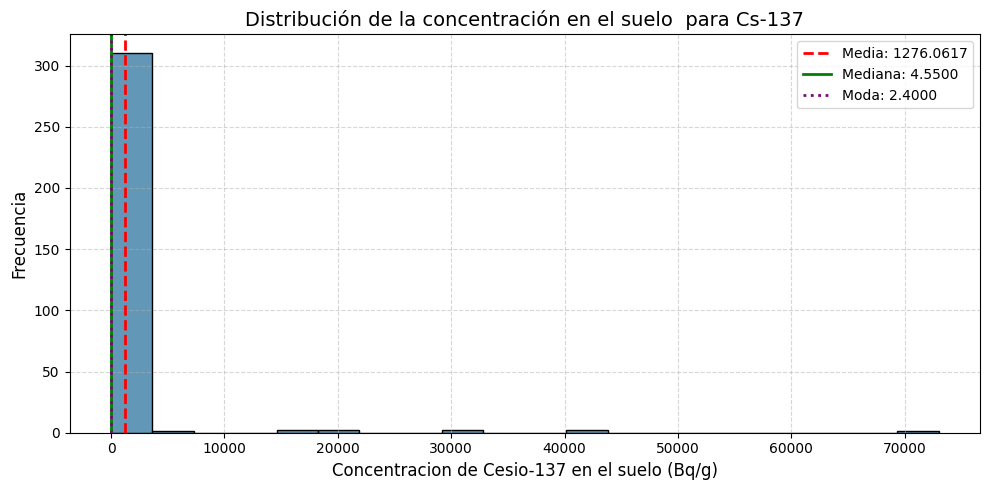

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Cargar el dataset
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Filtrar por el radionucleido Cs-137
# Usamos .copy() para evitar advertencias al limpiar los datos después
df_filtered = df[df['Radionuclide'] == 'Cs-137'].copy()

# 3. Limpieza de la variable CR en el set filtrado
df_filtered['CS_limpia'] = df_filtered['C_soil'].astype(str).str.replace('<', '')
df_filtered['CS_limpia'] = pd.to_numeric(df_filtered['CS_limpia'], errors='coerce')

# Quitar nulos para los cálculos
cr_data = df_filtered['CS_limpia'].dropna()

# 4. Medidas de tendencia central
media = np.mean(cr_data)
mediana = np.median(cr_data)
moda_res = stats.mode(cr_data, keepdims=True)
moda = moda_res.mode[0]

# Imprimir resultados
print(f"--- Estadísticas para Cs-137 (n={len(cr_data)}) ---")
print(f"Media:   {media:.4f}")
print(f"Mediana: {mediana:.4f}")
print(f"Moda:    {moda:.4f}")

# 5. Gráfico (Escala Lineal)
plt.figure(figsize=(10, 5))

# Histograma
sns.histplot(cr_data, bins=20, kde=False, color="#2F749F")

# Líneas de tendencia central
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.4f}')
plt.axvline(mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.4f}')
plt.axvline(moda, color='purple', linestyle=':', linewidth=2, label=f'Moda: {moda:.4f}')

plt.title("Distribución de la concentración en el suelo  para Cs-137", fontsize=14)
plt.xlabel("Concentracion de Cesio-137 en el suelo (Bq/kg)", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Al filtrar por Cs-137, la gráfica indica que el comportamiento de los datos no varía respecto a la gráfica anterior, que muestra la concentración de todos los elementos en el suelo. Esta gráfica presenta valores máximos que estan aportando a la media, lo que sugiere que la variabilidad no se debe solo a la mezcla de elementos (metales y radionúclidos), sino que refleja una distribución típica de los contaminantes en el suelo de ambientes tropicales.

La mediana de 4.55 Bq/kg presenta una concentración típica de la mayoría de las muestras, mientras que el promedio de 1276 Bq/kg está sobreestimada por unos pocos puntos con cincetraciones elevadas  (valores cerca a los 70,000Bq/kg).

Esta acumulación extrema en puntos específicos (outliers) puede deberse a eventos de deposición localizada. A diferencia de los minerales naturales, cuya distribución depende de factores geológicos y rocas madre que contienen estos radionúclidos, el Cs-137 llega al suelo principalmente mediante lluvia radiactiva (fallout). En zonas tropicales con precipitaciones intensas, el cesio puede ser lavado de un área y acumulado en depresiones o cuencas, formando "puntos calientes" o hotspots. Además, el cesio se adhiere fuertemente a ciertos tipos de arcilla, como la illita. Por lo tanto, si una muestra es rica en arcilla y otra más arenosa, la diferencia de concentración será masiva aunque estén cerca.

### <span style="color:#2F749F;"><strong>Parte 2: Cálculo de medidas de dispersión</strong></span>

1. Rango
2. Varianza
3. Desviación estándar
4. Coeficiente de variación
5. Genera una gráfica con los resultados obtenidos (ver imagen de ejemplo)

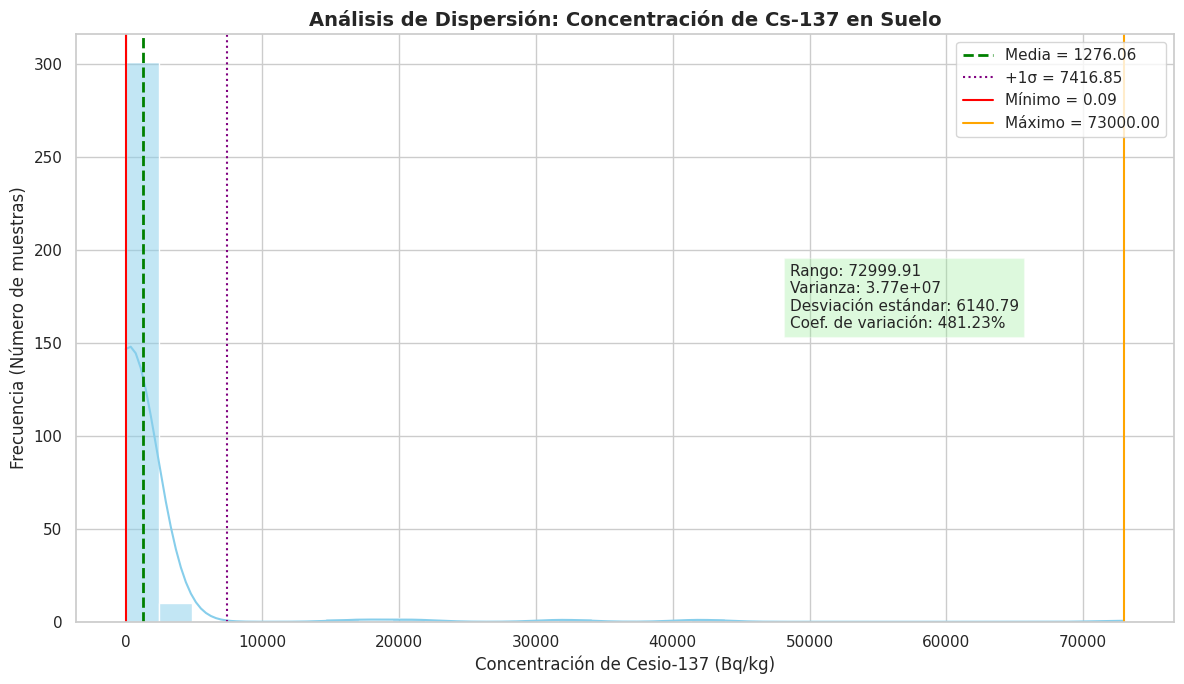

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Cargar el dataset
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Filtrar por el radionucleido Cs-137
df_filtered = df[df['Radionuclide'] == 'Cs-137'].copy()

# 3. Limpieza de la variable (C_soil)
df_filtered['CS_limpia'] = df_filtered['C_soil'].astype(str).str.replace('<', '')
df_filtered['CS_limpia'] = pd.to_numeric(df_filtered['CS_limpia'], errors='coerce')

# Definir la variable final libre de nulos
cr_data = df_filtered['CS_limpia'].dropna()

# 4. Medidas de tendencia central
media = np.mean(cr_data)
mediana = np.median(cr_data)
moda = stats.mode(cr_data, keepdims=True).mode[0]

# --- NUEVO: Cálculo de medidas de dispersión----
minimo = np.min(cr_data)
maximo = np.max(cr_data)
rango = maximo - minimo
varianza = np.var(cr_data, ddof=1) # ddof=1 para varianza muestral
desviacion = np.std(cr_data, ddof=1)
coef_var = (desviacion / media) * 100

# --- Visualización de Dispersión para Cs-137 ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Histograma de los datos filtrados
sns.histplot(cr_data, bins=30, kde=True, color='skyblue')

# Líneas de dispersión
plt.axvline(media, color='green', linestyle='--', linewidth=2, label=f'Media = {media:.2f}')
plt.axvline(media + desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'+1σ = {media + desviacion:.2f}')
# La línea -1σ la dibujo solo si es mayor que el mínimo para que no se salga del gráfico
if (media - desviacion) > minimo:
    plt.axvline(media - desviacion, color='purple', linestyle=':', linewidth=1.5, label=f'-1σ = {media - desviacion:.2f}')

plt.axvline(minimo, color='red', linestyle='-', linewidth=1.5, label=f'Mínimo = {minimo:.2f}')
plt.axvline(maximo, color='orange', linestyle='-', linewidth=1.5, label=f'Máximo = {maximo:.2f}')

# Configuración de etiquetas
plt.title("Análisis de Dispersión: Concentración de Cs-137 en Suelo", fontsize=14, fontweight='bold')
plt.xlabel("Concentración de Cesio-137 (Bq/kg)", fontsize=12)
plt.ylabel("Frecuencia (Número de muestras)", fontsize=12)
plt.legend(loc='upper right')

# Recuadro con medidas de dispersión.
texto = (
    f"Rango: {rango:.2f}\n"
    f"Varianza: {varianza:.2e}\n"  # Usamos notación científica para la varianza porque será muy grande
    f"Desviación estándar: {desviacion:.2f}\n"
    f"Coef. de variación: {coef_var:.2f}%"
)

# Ubicacion del texto en la parte media-derecha del gráfico
plt.text(0.65, 0.5, texto, transform=plt.gca().transAxes,
         bbox=dict(facecolor='lightgreen', alpha=0.3), fontsize=11)

plt.tight_layout()
plt.show()


Al analizar las medidas de dispersión de la concentración de Cs-137, el rango de 72999.91 Bq/kg muestra una desigualdad entre los datos, donde suelos con pocas concentraciones de 0.09 Bq/kg conviven con puntos de contaminación severa de 73000 Bq/kg, lo que confirma que la presencia de este radionúclido no es uniforme en el terreno.
Esta dispersión se refleja en la varianza de $3.77 \times 10^7$, indica que los datos están alejados del "centro" o promedio 1,276.06. Esto implica que la media no refleja adecuadamente la distribución del Cs-137, sino que es un cálculo sobrestimado debido a los datos atípicos. La desviación estándar de 6140.79, que casi quintuplica la media, refuerza esta idea. Esta dispersión se refleja en la varianza de $3.77 \times 10^7$, un valor que indica que los datos están  alejados del "centro" o promedio 1276.06, esto significa que esta media no es un valor que represente la distribución del Cs-137, sino un cálculo matemático sobrestimado por los datos atipicos.
La desviación estándar de 6140.79, al ser casi cinco veces mayor que la media, confirma que el promedio no es una medida confiable, ya que la distancia común entre cualquier muestra y ese valor central es tan grande que la media no logra resumir la realidad del suelo.
Finalmente, el coeficiente de variación del $481.23\%$ muestra que la mayoría del suelo tiene niveles bajos y solo unos pocos puntos concentran casi toda la radiactividad, lo cual se explica porque el Cs-137 llegó por lluvia y el agua en climas tropicales lo arrastró de las laderas para amontonarlo en las zonas bajas, creando hotspots.

### <span style="color:#2F749F;"><strong>Parte 3: Cálculo de medidas de distribución</strong></span>

A partir de la muestra generada en el Ejercicio 1, analiza la distribución de los datos. Calcula:
1. Asimetría
2. Curtosis
3. Realiza la comparación con la distribución normal

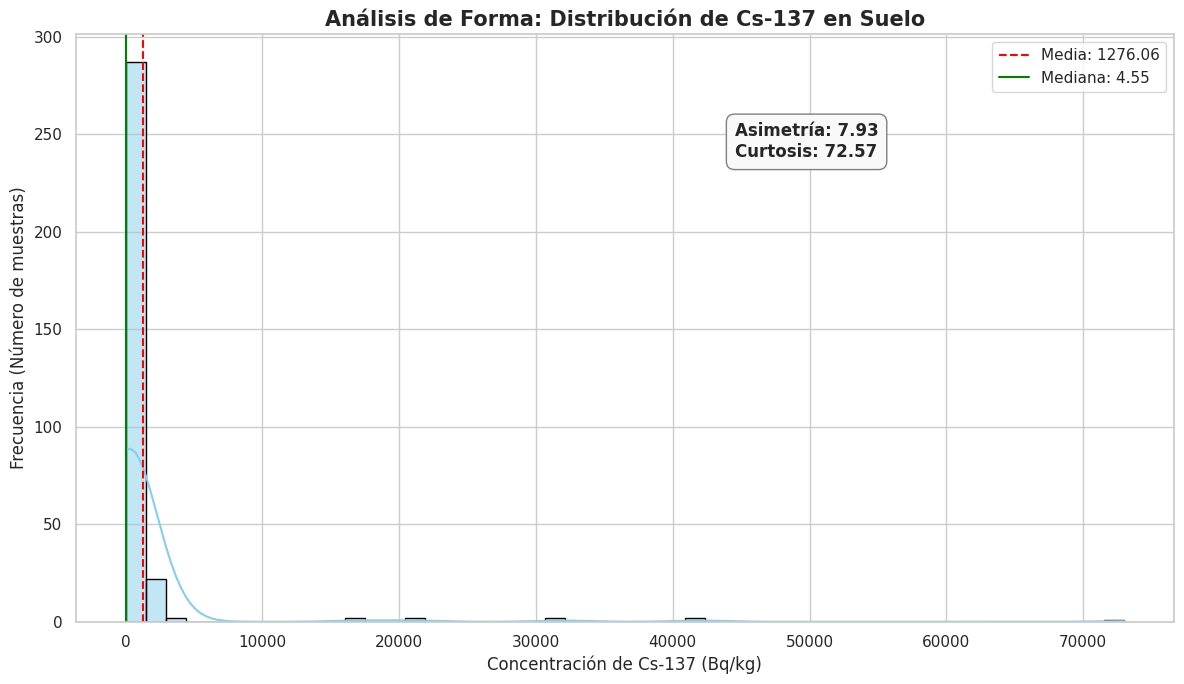

Resultados para Cs-137:
Asimetría: 7.93
Curtosis: 72.57


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# 1. Cargar el dataset directamente desde la fuente de la IAEA
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Filtrar por el radionucleido Cs-137
df_filtered = df[df['Radionuclide'] == 'Cs-137'].copy()

# 3. Limpieza de la variable de concentración en suelo (C_soil)
# Eliminamos caracteres de límite de detección (<) y convertimos a número
df_filtered['CS_limpia'] = df_filtered['C_soil'].astype(str).str.replace('<', '')
df_filtered['CS_limpia'] = pd.to_numeric(df_filtered['CS_limpia'], errors='coerce')

# Definir la serie final eliminando valores nulos
cr_data = df_filtered['CS_limpia'].dropna()

# 4. Cálculo de medidas de forma
asimetria_val = skew(cr_data)
curtosis_val = kurtosis(cr_data, fisher=True)

# 5. Visualización siguiendo el estilo de la profesora
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Histograma con KDE (Línea de densidad)
ax = sns.histplot(cr_data, kde=True, color='skyblue', bins=50, edgecolor="black")

# Personalización de títulos y etiquetas
plt.title("Análisis de Forma: Distribución de Cs-137 en Suelo", fontsize=15, fontweight='bold')
plt.xlabel("Concentración de Cs-137 (Bq/kg)", fontsize=12)
plt.ylabel("Frecuencia (Número de muestras)", fontsize=12)

# Cuadro de texto con los resultados estadísticos
plt.text(0.6, 0.85,
         f"Asimetría: {asimetria_val:.2f}\nCurtosis: {curtosis_val:.2f}",
         transform=ax.transAxes,
         fontsize=12,
         verticalalignment='top',
         fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="gray"))

# Añadir líneas para media y mediana para reforzar el análisis anterior
plt.axvline(cr_data.mean(), color='red', linestyle='--', label=f'Media: {cr_data.mean():.2f}')
plt.axvline(cr_data.median(), color='green', linestyle='-', label=f'Mediana: {cr_data.median():.2f}')
plt.legend()

plt.tight_layout()
plt.show()

# Imprimir resultados en consola para verificar
print(f"Resultados para Cs-137:")
print(f"Asimetría: {asimetria_val:.2f}")
print(f"Curtosis: {curtosis_val:.2f}")

La distribución muestra resultados que corroboran la naturaleza atípica del Cs-137 en este estudio. Los coeficientes confirman que su distribución difiere de una normal, donde ambos valores serían 0. La asimetría de 7.93 indica un sesgo positivo significativo, con mayor concentración en los valores bajos y una "cola' extendiéndose hacia las concentraciones altas. Este valor explica por qué la mediana 4.55$ Bq/kg es menor que la media 1276.06 Bq/kg, demostrando que el promedio está sobreestimado por los valores extremos.

La Curtosis de 72.57 define una distribución leptocúrtica, caracterizada por una concentración masiva de datos en un rango estrecho y una frecuencia de valores atípicos. En términos radioecológicos, estas métricas prueban que el Cs-137 no se distribuye de forma aleatoria o uniforme, sino que su presencia en el suelo está gobernada por procesos de acumulación específica o hotspots.


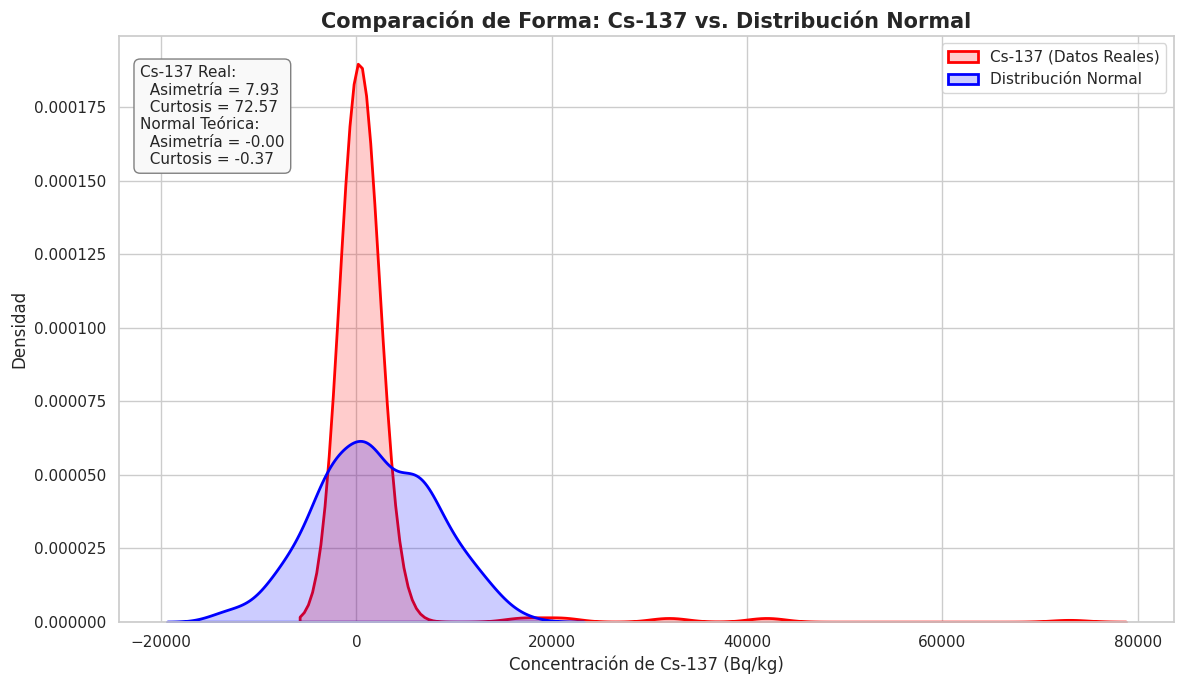

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, norm

# 1. Cargar y limpiar datos (proceso que ya tienes)
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)
df_filtered = df[df['Radionuclide'] == 'Cs-137'].copy()
df_filtered['CS_limpia'] = pd.to_numeric(df_filtered['C_soil'].astype(str).str.replace('<', ''), errors='coerce')
cr_data = df_filtered['CS_limpia'].dropna()

# 2. Crear una distribución normal teórica para comparar
# Usamos la misma media y desviación de tus datos para ver la diferencia de forma
mu, std = cr_data.mean(), cr_data.std()
normal_teorica = np.random.normal(mu, std, size=len(cr_data))

# 3. Cálculo de métricas
metrics = {
    'Cs-137 Real': {'data': cr_data, 'color': 'red', 'label': 'Cs-137 (Datos Reales)'},
    'Normal Teórica': {'data': normal_teorica, 'color': 'blue', 'label': 'Distribución Normal'}
}

for key in metrics:
    datos = metrics[key]['data']
    metrics[key]['skew'] = skew(datos)
    metrics[key]['kurtosis'] = kurtosis(datos, fisher=True)

# 4. Visualización
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

for key in metrics:
    sns.kdeplot(metrics[key]['data'], label=metrics[key]['label'],
                color=metrics[key]['color'], linewidth=2, fill=True, alpha=0.2)

# Anotaciones (Estilo de la profesora)
texto = "\n".join([
    f"{key}:\n  Asimetría = {metrics[key]['skew']:.2f}\n  Curtosis = {metrics[key]['kurtosis']:.2f}"
    for key in metrics
])

plt.text(0.02, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.4", facecolor='#f9f9f9', edgecolor="gray"))

plt.title('Comparación de Forma: Cs-137 vs. Distribución Normal', fontsize=15, fontweight='bold')
plt.xlabel('Concentración de Cs-137 (Bq/kg)')
plt.ylabel('Densidad')
plt.legend(loc="upper right")

# Ajustar escala si los hotspots no dejan ver la curva (opcional)
# plt.xlim(-1000, 15000)

plt.tight_layout()
plt.show()

Para evaluar la naturaleza de la dispersión, se generó una distribución normal teórica (curva azul) utilizando la media ($\mu = 1,276.06$) y la desviación estándar ($\sigma = 6,140.79$) calculadas a partir del set de datos; este modelo representa el escenario ideal donde el Cs-137 se hubiera depositado y acumulado de forma homogénea en el suelo, presentando una asimetría de cero.
Al comparar este modelo con la distribución real (curva roja), se evidencia que los datos no siguen un patrón gaussiano, sino que presentan una forma leptocúrtica extrema con una curtosis de 72.57.
Mientras la campana azul muestra una probabilidad distribuida de forma suave, la curva roja muestra un pico estrecho y elevado cerca de bajas concentraciones, indicando que la gran mayoría de las muestras poseen concentraciones bajas de Cs-137. Sin embargo, la asimetría de $7.93$ en los datos reales genera una "cola" o sesgo hacia la derecha que el modelo normal es incapaz de capturar, confirmando que la presencia de hotspots o puntos críticos de contaminación rompe la simetría teórica.
Esta comparación muestra que la distribución del Cs-137 en el suelo está influenciada por valores atípicos que invalidan el uso del promedio como medida representativa y requieren un análisis centrado en la heterogeneidad espacial.

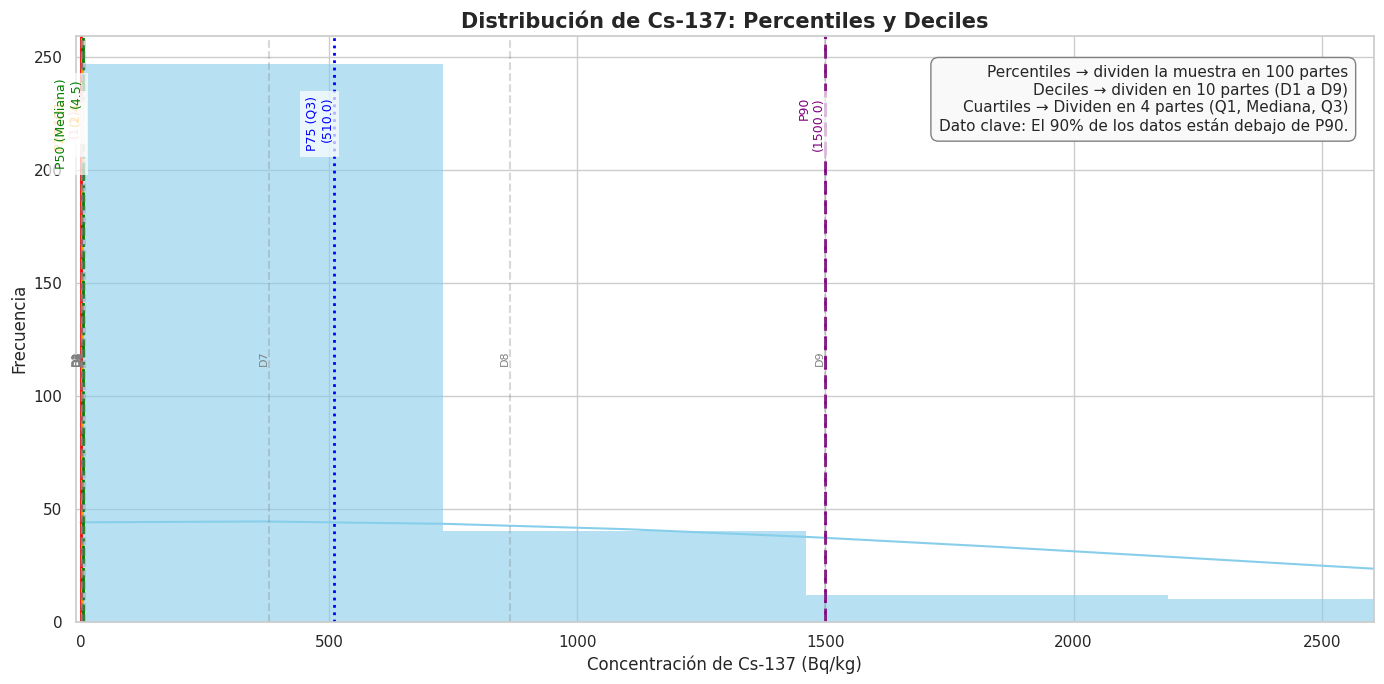

--- Tabla de Posición ---
P10: 1.10 Bq/kg
P25 (Q1): 2.40 Bq/kg
P50 (Mediana): 4.55 Bq/kg
P75 (Q3): 510.00 Bq/kg
P90: 1500.00 Bq/kg


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo visual
sns.set_theme(style="whitegrid")

# 2. Cálculo de percentiles clave para Cs-137
percentiles = {
    'P10': {'valor': np.percentile(cr_data, 10), 'color': 'red', 'linestyle': '-'},
    'P25 (Q1)': {'valor': np.percentile(cr_data, 25), 'color': 'orange', 'linestyle': '--'},
    'P50 (Mediana)': {'valor': np.percentile(cr_data, 50), 'color': 'green', 'linestyle': '-.'},
    'P75 (Q3)': {'valor': np.percentile(cr_data, 75), 'color': 'blue', 'linestyle': ':'},
    'P90': {'valor': np.percentile(cr_data, 90), 'color': 'purple', 'linestyle': (0, (5, 2))}
}

# 3. Cálculo de deciles (D1 a D9)
deciles = {f'D{i}': np.percentile(cr_data, i * 10) for i in range(1, 10)}

# 4. Visualización
plt.figure(figsize=(14, 7))

# Nota: Usar bins=100 porque los datos tienen mucha dispersión
sns.histplot(cr_data, kde=True, color='skyblue', bins=100, edgecolor="None", alpha=0.6)

# Líneas verticales de percentiles
for etiqueta, props in percentiles.items():
    plt.axvline(props['valor'], color=props['color'], linestyle=props['linestyle'], linewidth=2)
    # Ajustar la altura del texto para que no se amontone
    plt.text(props['valor'], plt.ylim()[1]*0.85, f"{etiqueta}\n({props['valor']:.1f})",
             rotation=90, color=props['color'], fontsize=9,
             verticalalignment='center', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Líneas verticales de deciles
for etiqueta, valor in deciles.items():
    plt.axvline(valor, color='gray', linestyle='--', alpha=0.3)
    plt.text(valor, plt.ylim()[1]*0.45, etiqueta,
             rotation=90, color='gray', fontsize=8,
             verticalalignment='center', horizontalalignment='right')

# Cuadro de texto explicativo (estilo profe)
texto = (
    "Percentiles → dividen la muestra en 100 partes\n"
    "Deciles → dividen en 10 partes (D1 a D9)\n"
    "Cuartiles → Dividen en 4 partes (Q1, Mediana, Q3)\n"
    "Dato clave: El 90% de los datos están debajo de P90.")

plt.text(0.98, 0.95, texto, transform=plt.gca().transAxes,
         fontsize=11, verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#f9f9f9", edgecolor="gray"))

# Limitamos el eje X para que los percentiles sean visibles
# (Si no, el hotspot de 73,000 los dejaría todos pegados a la izquierda)
plt.xlim(-10, np.percentile(cr_data, 95))

plt.title("Distribución de Cs-137: Percentiles y Deciles", fontsize=15, fontweight='bold')
plt.xlabel("Concentración de Cs-137 (Bq/kg)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

# Imprimir tabla de valores para el análisis
print("--- Tabla de Posición ---")
for p, info in percentiles.items():
    print(f"{p}: {info['valor']:.2f} Bq/kg")

La visualización de los percentiles confirma  variabilidad  en la distribución de las concentraciones de cesio en el suelo. El hecho de que el 50% de las muestras (Mediana) se sitúe en apenas 4.55 Bq/kg, mientras que el 90% (P90) se incremente hasta los 1500 Bq/kg, evidencia una distribución con una cola derecha debido a los outliers y valores con altas conetraciones.
Se observa una brecha de magnitud entre la base de la muestra y los valores extremos: el P90 es más de 300 veces superior a la mediana. La alta densidad de deciles (D1 a D6) acumulados cerca del origen indica que la gran mayoría de las observaciones presentan concentraciones bajas.
El amplio intervalo hacia la derecha representa la cola derecha con los valores elevados de la distribución, donde se ubican los hotspots.
En conclusión, los percentiles demuestran que el valor de la media 1,276.06 Bq/kg solo se alcanza a partir del percentil 85, lo que confirma que el promedio no es una medida de tendencia central representativa para la mayor parte del conjunto de datos, sino que está sesgado por el 15% de las muestras con mayor actividad.

# Conclusion Análisis Univariado
El análisis univariado ha permitido identificar que el Cs-137 presenta una distribución con una variabilidad extrema y una presencia dominante de puntos críticos (hotspots). Sin embargo, los resultados demuestran que este enfoque estadístico es insuficiente para cumplir con los objetivos generales de la investigación por tres razones fundamentales:

Ocultamiento de la tendencia central: Debido al sesgo provocado por los valores atípicos, es imposible caracterizar el comportamiento de las muestras con concentraciones bajas, que representan la mayor parte del terreno estudiado.

Inconsistencia del promedio: La media aritmética, al estar influenciada por la "cola pesada" de la distribución, pierde su valor como descriptor representativo, impidiendo un análisis comparativo fiable con otros radionucleidos.

Necesidad de procesamiento avanzado: Se concluye que un análisis descriptivo básico es limitante si no se aplican técnicas de transformación de datos (como escalas logarítmicas) o la segmentación de valores atípicos para normalizar la muestra.

En definitiva, aunque el análisis univariado confirma la heterogeneidad del suelo, resulta insuficiente para entender las relaciones causales del Cs-137. Por tanto, es imperativo transitar hacia un análisis bivariado y multivariado que permita cruzar estos datos con otras variables fisicoquímicas, buscando patrones que la estadística descriptiva simple no logra revelar.

# Analisis Bivariado

### <span style="color:#2F749F;"><strong>Parte 4: Coeficiente de Pearson</strong></span>
Utilizo el coeficiente de Pearson para analizar la relación entre el Contenido de Arcilla (Clay) y la Capacidad de Intercambio Catiónico (CEC), ya que ambas son variables numéricas continuas que representan propiedades críticas del suelo en ambientes tropicales.Esta elección es fundamental para ayudar a resolver la pregunta de investigación, ya que la arcilla es el principal componente del suelo, encargado de retener metales pesados y radionúclidos. Según la definición, Pearson evalúa la 'fuerza lineal'; por tanto, este análisis me permite comprobar si existe un aumento constante y proporcional en la capacidad de retención del suelo a medida que aumenta la fracción de arcilla y determinar si esta relación es el primer paso para entender por qué ciertos suelos tropicales acumulan más radionúclidos que otros, estableciendo la base fisicoquímica de la disponibilidad de estos elementos para las plantas.

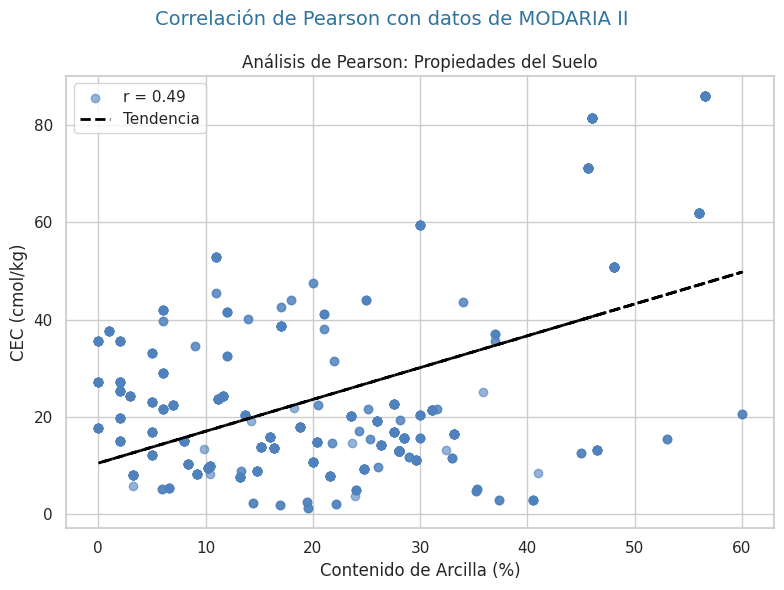

Resultados del análisis:
Variable X: Clay (Arcilla)
Variable Y: CEC (Capacidad de Intercambio Catiónico)
Coeficiente r de Pearson: 0.4923


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# 1. Carga del dataset
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Limpieza de datos (Variables para Pearson)
# Se usa Clay (Arcilla) y CEC (Capacidad de intercambio)
df['Clay'] = pd.to_numeric(df['Clay'], errors='coerce')
df['CEC'] = pd.to_numeric(df['CEC'], errors='coerce')

# Se filtran los nulos para que Pearson no de error
df_pearson = df[['Clay', 'CEC']].dropna()

# 3. Cálculo del coeficiente de Pearson
r, _ = pearsonr(df_pearson['Clay'], df_pearson['CEC'])

# 4. Función de visualización (Estilo exacto de la profe)
def plot_corr_real(ax, x, y, r, title, color, xlabel, ylabel):
    ax.scatter(x, y, alpha=0.6, color=color, label=f"r = {r:.2f}")

    # Línea de tendencia (Ajuste lineal)
    m, b = np.polyfit(x, y, 1)
    ax.plot(x, m*x + b, color="black", linewidth=2, linestyle="--", label="Tendencia")

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

# 5. Generar la gráfica
fig, ax = plt.subplots(figsize=(8, 6))

plot_corr_real(
    ax,
    df_pearson['Clay'],
    df_pearson['CEC'],
    r,
    "Análisis de Pearson: Propiedades del Suelo",
    "#4F81BD", # Color azul del ejemplo de la profe
    "Contenido de Arcilla (%)",
    "CEC (cmol/kg)"
)

plt.suptitle("Correlación de Pearson con datos de MODARIA II", fontsize=14, color="#2F749F")
plt.tight_layout()
plt.show()

# Resumen para tu tarea
print(f"Resultados del análisis:")
print(f"Variable X: Clay (Arcilla)")
print(f"Variable Y: CEC (Capacidad de Intercambio Catiónico)")
print(f"Coeficiente r de Pearson: {r:.4f}")

El coeficiente de Pearson obtenido es 0.4923, según la escala de interpretación, este valor se clasifica como una correlación positiva moderada.

La dirección es positiva, lo que significa que existe una relación directamente proporcional: a medida que aumenta el porcentaje de arcilla en el suelo, la Capacidad de Intercambio Catiónico (CEC) también tiende a aumentar.

La relación tiene una fuerza moderada. Aunque los puntos muestran cierta dispersión y no están completamente alineados con la línea de tendencia , la tendencia ascendente es evidente.
Los resultados muestran que el contenido de arcilla explica una parte importante de la variabilidad de la CEC en estos suelos tropicales. Esto es importante porque la CEC representa la "capacidad de carga" del suelo; es decir, cuántos radionúclidos y metales pesados puede retener el suelo en sus partículas antes de que saturen el sistema.

Al confirmar esta correlación, puedo deducir que los suelos con texturas más arcillosas ofrecen más sitios de unión química para los cationes metálicos, incluyendo los radionúclidos de interés.

Esto sugiere que la arcilla actúa como un factor regulador, controlando la disponibilidad de estos isótopos metálicos en el suelo. Al quedar atrapados en la estructura de la arcilla, se reduce su movilidad y, por tanto, su probabilidad de ser absorbidos por las raíces de las plantas.

En este contexto, la arcilla no distingue si el metal es estable o radiactivo; su carga eléctrica negativa atrapa a ambos por igual. Sin embargo, para esta investigación, esto es vital porque determina qué tan "peligroso" es el suelo: cuanto más arcilla, el radionúclido está más contenido en la matriz y llega menos a la planta.

### <span style="color:#2F749F;"><strong>Parte 5: Coeficiente de Spearman</strong></span>


Seleccione el coeficiente de Spearman ($\rho$) para evaluar la relación entre el pH del suelo y el Ratio de Concentración (CR). Esta elección es fundamental para ayudar a resolver la pregunta de investigación por tres razones basadas en la definición técnica:
- Relación No Lineal: La absorción de radionúclidos por las plantas tropicales no sigue una línea recta proporcional respecto al pH.
- Valores Atípicos: Como se observa en el gráfico, el dataset presenta una alta dispersión con valores extremos de absorción.
- Influencia en Compartimentos: Este análisis permite entender cómo las propiedades químicas del suelo condicionan la acumulación inicial de metales, determinando si el pH actúa como una barrera o un facilitador para la entrada de radionúclidos a los diferentes compartimientos de las plantas.

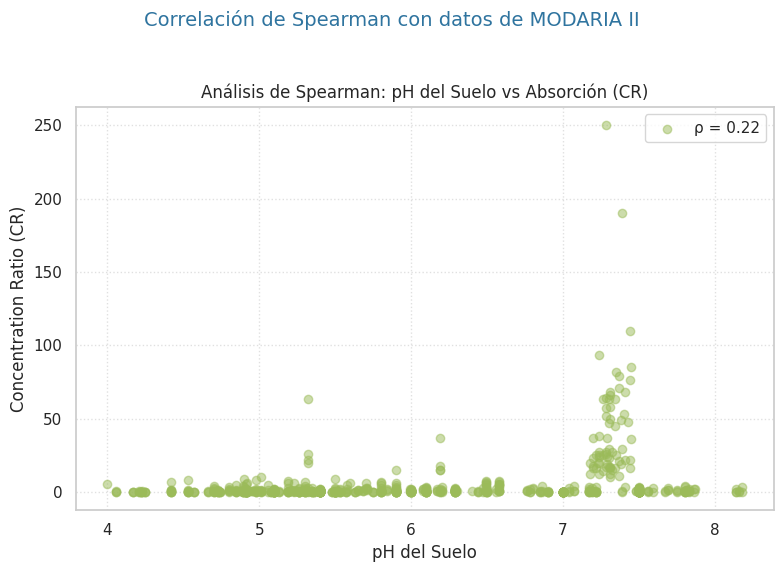

Coeficiente rho de Spearman: 0.2229


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# 1. Carga del dataset
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Limpieza de datos
df['pH'] = pd.to_numeric(df['pH'], errors='coerce')
df['CR'] = pd.to_numeric(df['CR'], errors='coerce')

# Filtramos nulos para el análisis de Spearman
df_spearman = df[['pH', 'CR']].dropna()

# 3. Cálculo de Spearman
rho, _ = spearmanr(df_spearman['pH'], df_spearman['CR'])

# 4. Función de visualización (Basada en el ejemplo de tu profe)
def plot_spearman_real(ax, x, y, rho, title, color, xlabel, ylabel):
    ax.scatter(x, y, alpha=0.5, color=color, label=f"ρ = {rho:.2f}")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

# 5. Visualización (Mantenemos la estructura de la profe aunque sea un solo gráfico central)
fig, ax = plt.subplots(figsize=(8, 6))

plot_spearman_real(
    ax,
    df_spearman['pH'],
    df_spearman['CR'],
    rho,
    "Análisis de Spearman: pH del Suelo vs Absorción (CR)",
    "#9BBB59", # El verde del ejemplo de relación decreciente de la profe
    "pH del Suelo",
    "Concentration Ratio (CR)"
)

plt.suptitle("Correlación de Spearman con datos de MODARIA II", fontsize=14, color="#2F749F")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Resumen para tu tarea
print(f"Coeficiente rho de Spearman: {rho:.4f}")

El análisis de correlación de Spearman reveló un coeficiente de 0.2229, indicando una correlación positiva débil entre el pH del suelo y el Ratio de Concentración (CR). Este valor de 0.22 sugiere que, aunque hay una ligera tendencia a que la absorción aumente con niveles más altos de pH, la relación no es fuerte debido a la dispersión de los datos. Este hallazgo muestra que el pH del suelo, por sí solo, no determina de manera lineal la absorción de radionúclidos en las plantas del dataset, ya que otros factores biológicos y ambientales, como la especie de planta o la naturaleza específica del radionúclido, también influyen. Es importante resaltar una observación clave en el gráfico: el "estallido" de puntos altos detectado entre pH 7.2 y 7.5. Esto indica que la mayor variabilidad en la absorción se presenta en suelos con pH neutro o ligeramente alcalino, donde la solubilidad de ciertos metales puede aumentar, facilitando su entrada en las plantas.
En conclusión, dado que las propiedades fisicoquímicas del suelo, como el pH y la arcilla, solo explican parcialmente esta absorción suelo-planta, es fundamental explorar más la dimensión biológica para determinar si la acumulación final depende específicamente del compartimento de la planta donde se almacena el metal.

# Conclusion Pearson y Spearman
Mi pregunta de investigación es ¿Cómo se relaciona la presencia de metales pesados y las propiedades del suelo con la absorción y acumulación de radionúclidos en los diferentes compartimentos de las plantas tropicales (raíz, tallo y hojas)?
Para abordar esta pregunta, se llevó a cabo un análisis bivariado empleando los coeficientes de Pearson y Spearman, que facilitan la comprensión de la retención física en el suelo y la dinámica de transferencia hacia la planta.

En primer lugar, se aplicó el Coeficiente de Pearson ($r$) para analizar la relación entre el contenido de arcilla (Clay) y la Capacidad de Intercambio Catiónico (CEC). El resultado obtenido de $r = 0.4923$ indica una correlación positiva moderada. Desde la perspectiva de la pregunta de investigación, esto confirma que la propiedad física del suelo (arcilla) define directamente la capacidad química de retención de metales. Esto significa que los suelos tropicales con texturas más finas actúan como un reservorio lineal de radionúclidos, controlando la cantidad de elementos que potencialmente estarán disponibles para la planta.
Para entender como el pH ayuda a la trasferencia de elementos de la matriz suelo a los compartimientos de la planta, se utilizó el coeficiente de Spearman ($\rho$) relacionando el pH del suelo con el Ratio de Concentración (CR). El análisis arrojó un $\rho = 0.2229$, lo que estadísticamente representa una correlación positiva débil. Este resultado revela que, si bien el pH influye en la química del sistema, la absorción de radionúclidos por las plantas no sigue un patrón lineal simple, sino que es un proceso altamente variable afectado por otros factores biológicos.
Un hallazgo importante fue identificar una acumulación de puntos de alta absorción en rangos de pH entre 7.2 y 7.5; esto indica que a estos valores de pHla solubilidad de los metales aumenta facilitando su entrada por la raiz para distribuirse en los compartimientos de la planta.
 En resumen, mientras Pearson muestra que el suelo retiene los metales en proporción a su contenido de arcilla, Spearman señala que la absorción de estos es un proceso más complejo y menos predecible. Estos resultados sugieren que, para entender completamente cómo se acumulan los radionúclidos en la planta, no basta con analizar las propiedades del suelo; también es fundamental evaluar cómo los isótopos se relacionan específicamente con los diferentes órganos vegetales (raíz, tallo, hojas).

### <span style="color:#2F749F;"><strong>Parte 6: Chi-cuadrada</strong></span>


Para responder si la acumulación de contaminantes depende del compartimiento, se aplicó la prueba de Chi-cuadrado de independencia utilizando las variables categóricas Radionuclide (como variable independiente) y Compartment (como variable dependiente).

Según la definición, esta prueba permite determinar si existe una asociación estadísticamente significativa entre dos categorías.Para resolver la pregunta de investigación, esto es fundamental para verificar si la distribución de los radionúclidos en la planta es aleatoria o si, por el contrario, existen isótopos específicos que tienen una preferencia para acumularse en algun comppartimiento. Si el p-valor es menor a 0.05, se confirma que la fisiología de la planta tropical interactúa de forma distinta con cada metal, lo cual es crítico para entender los riesgos de transferencia a la cadena alimentaria (por ejemplo, si un metal se queda en la raíz no comestible o sube a las hojas/frutos)

P-valor: 7.8668e-22


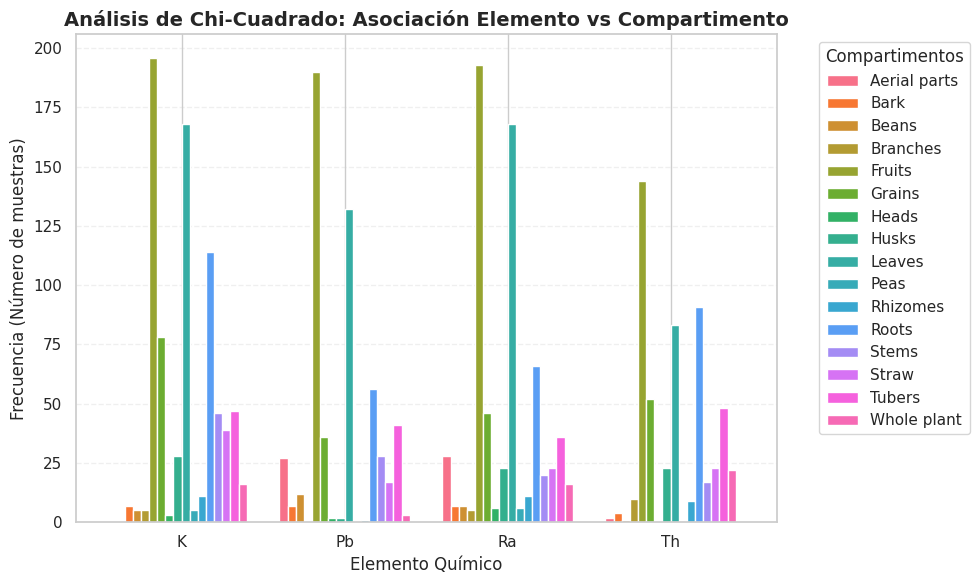

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# 1. Carga
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

# 2. Selección  de datos
# Selección de radionúclidos que tengan datos en varios compartimentos
# Usar 'Element' en lugar de 'Radionuclide' para agrupar más datos y que salga la gráfica
top_elements = df['Element'].value_counts().nlargest(4).index
df_chi = df[df['Element'].isin(top_elements)]

# Solo compartimentos con suficientes muestras (filtrar para que no salga vacío)
counts = df_chi['Compartment'].value_counts()
principales = counts[counts > 10].index
df_chi = df_chi[df_chi['Compartment'].isin(principales)]

# 3. Tabla de Contingencia
tabla_contingencia = pd.crosstab(df_chi['Element'], df_chi['Compartment'])

# 4. Prueba Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

# 5. Visualización Mejorada
print(f"P-valor: {p:.4e}")

# En lugar de una lista manual, usamos una paleta que genere tantos colores como columnas haya
import seaborn as sns
num_columnas = len(tabla_contingencia.columns)
colores_dinamicos = sns.color_palette("husl", num_columnas) # 'husl' da colores bien diferenciados

ax = tabla_contingencia.plot(kind="bar",
                             width=0.8,
                             figsize=(10, 6),
                             color=colores_dinamicos)

ax.set_title("Análisis de Chi-Cuadrado: Asociación Elemento vs Compartimento", fontsize=14, fontweight='bold')
ax.set_ylabel("Frecuencia (Número de muestras)")
ax.set_xlabel("Elemento Químico")

# Ajustamos la leyenda para que no tape el gráfico
ax.legend(title="Compartimentos", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=0) # Para que los nombres de los elementos (K, Cs, etc) se lean rectos
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Para resolver la parte de la pregunta de investigación centrada en la ubicación de los contaminantes, se plantea si la acumulación de radionúclidos depende del órgano vegetal o si se distribuye de forma aleatoria. El análisis arrojó un p-valor de $7.86 \times 10^{-22}$, un resultado estadísticamente contundente que nos permite rechazar la hipótesis de independencia.
Esto confirma que existe una asociación muy fuerte entre el tipo de elemento químico (K, Pb, Ra, Th) y el compartimento de la planta donde se deposita. Al observar el gráfico de barras, la interpretación biológica es evidente: la acumulación no es uniforme y sigue patrones específicos de transporte de nutrientes y metales.
La gráfica muestra que el compartimiento predominante de Fruits (sin embargo, recordar que en alprimera entrega evidenciamos el sesgo hacia este compartimiento) y Leaves (barras turquesas) en casi todos los elementos. Para el potasio (K) y el radio (Ra), la frecuencia en hojas y frutos es considerablemente alta, indicando una translocación eficaz desde la raíz hacia las partes activas metabólicamente y de almacenamiento.

Por el contrario, elementos pesados como el Plomo (Pb) y el Torio (Th), aunque también llegan a los frutos, muestran una presencia importante en las raíces (Roots, barras azules claras), lo que indica que una parte de estos elementos queda retenida en la base de la planta.

Esta selectividad revela que la fisiología de las plantas tropicales interactúa diferente con cada radionúclido. Este descubrimiento es clave para la seguridad alimentaria: dado que la mayoría de las muestras provienen de frutos y hojas, el riesgo de transferencia a la cadena alimentaria es considerablemente mayor que si los contaminantes permanecieran solo en partes estructurales como la corteza o las ramas.

# Conclusion Analisis Bivariado
La pregunta que me plante en el transcurso del curso es ¿Cómo se relaciona la presencia de metales pesados y las propiedades del suelo con la absorción y acumulación de radionúclidos en los diferentes compartimentos de las plantas tropicales (raíz, tallo y hojas)? y al integrar los tres niveles de análisis estadístico, podemos concluir que:
- En el análisis de Pearson ($r = 0.49$), demostró que la propiedad física del suelo, específicamente la arcilla, es el primer filtro. La arcilla determina de forma lineal la "capacidad de carga" (CEC) del sistema, indicando cuánta contaminación puede retener el suelo antes de llegar a la planta.
- El análisis de Spearman ($\rho = 0.22$) en la interfaz suelo-planta mostró que la absorción real no es tan predecible como la retención en el suelo. El pH funciona como un modulador complejo que, aunque no sigue una relación lineal, presenta puntos críticos de acumulación en niveles neutros, donde la planta absorbe metales en forma acelerada.
- En la Planta (Chi-Cuadrado):la prueba de Chi-cuadrado confirmó que, una vez dentro de la planta, los metales no se reparten al azar. Su destino final (raíz, tallo o fruto) está determinado por la identidad química de cada radionúclido.

En conclusión, la respuesta a la pregunta de investigación es que la acumulación de radionúclidos es un fenómeno multivariado. No se puede entender la contaminación en plantas tropicales analizando solo el suelo o solo la planta; es la combinación de la textura del suelo, la acidez del entorno y la selectividad biológica de los órganos vegetales lo que determina el impacto final de estos elementos en el ecosistema.

# Analisis Multivariado

### <span style="color:#2F749F;"><strong>Parte 7: Analisis de componentes principales</strong></span>
Tras haber analizado las correlaciones individuales entre las propiedades del suelo y la transferencia a la planta, se procede a realizar un análisis de Componentes Principales (PCA). Este enfoque multivariado es fundamental como mostro el analisis univariado y bivariado, en la naturaleza, variables como el pH, la arcilla y la CEC no actúan de forma aislada, sino que interactúan simultáneamente para determinar la absorción de radionúclidosen los diferentes compartimientos de la planta.

El objetivo principal de aplicar el PCA es reducir la complejidad del dataset original sin perder la información esencial. Al transformar las variables en Componentes Principales, podemos identificar qué factores (físicos o químicos) tienen un peso mayor en la variabilidad del sistema y cómo estos definen el comportamiento de los diferentes elementos analizados.

Para este análisis, se seleccionaron cuatro variables críticas: pH, contenido de Arcilla (Clay), Capacidad de Intercambio Catiónico (CEC) y el Factor de Transferencia (CR). Esta combinación permite observar en un solo modelo la relación entre la estructura del suelo, su reactividad química y el resultado biológico final en la planta.

El análisis se enfoca en cuatro elementos representativos (K, Cs, Sr, Ra). Esta elección forma parte de una estrategia que busca afrontar la complejidad de los ecosistemas tropicales desde tres perspectivas clave: la analogía química, el riesgo radiológico y la robustez estadística.

En primer lugar, estos elementos permiten observar el fenómeno de analogía química. En el suelo, el Cesio (Cs) se comporta de manera similar al Potasio (K), mientras que el Estroncio (Sr) y el Radio (Ra) actúan de forma análoga al Calcio. Al incluirlos en un mismo modelo, el PCA puede identificar si las plantas absorben estos radionúclidos por un "error" metabólico al intentar captar nutrientes esenciales.

Por otra parte, estos elementos representan los mayores riesgos radiológicos a largo plazo. Isótopos como el Cs-137 y el Sr-90 son productos de fisión con vidas medias largas que persisten durante décadas en el suelo, mientras que el Ra-226 es un componente natural clave de la cadena de desintegración del Uranio. Por su movilidad y permanencia, su estudio es prioritario para garantizar la seguridad alimentaria en regiones tropicales.

Por último, esta elección de estos elementos busca maximizar la robustez estadística del modelo. Al filtrar el dataset hacia estos cuatro grupos bien definidos, se reduce significativamente la dispersión que generarían los elementos con pocos datos. Esto permite que el PCA resalte con mayor precisión cómo las propiedades del suelo (pH, Arcilla y CEC) afectan a familias químicas específicas, facilitando la identificación de patrones de agrupación que, en un conjunto de datos global, quedarían ocultos.

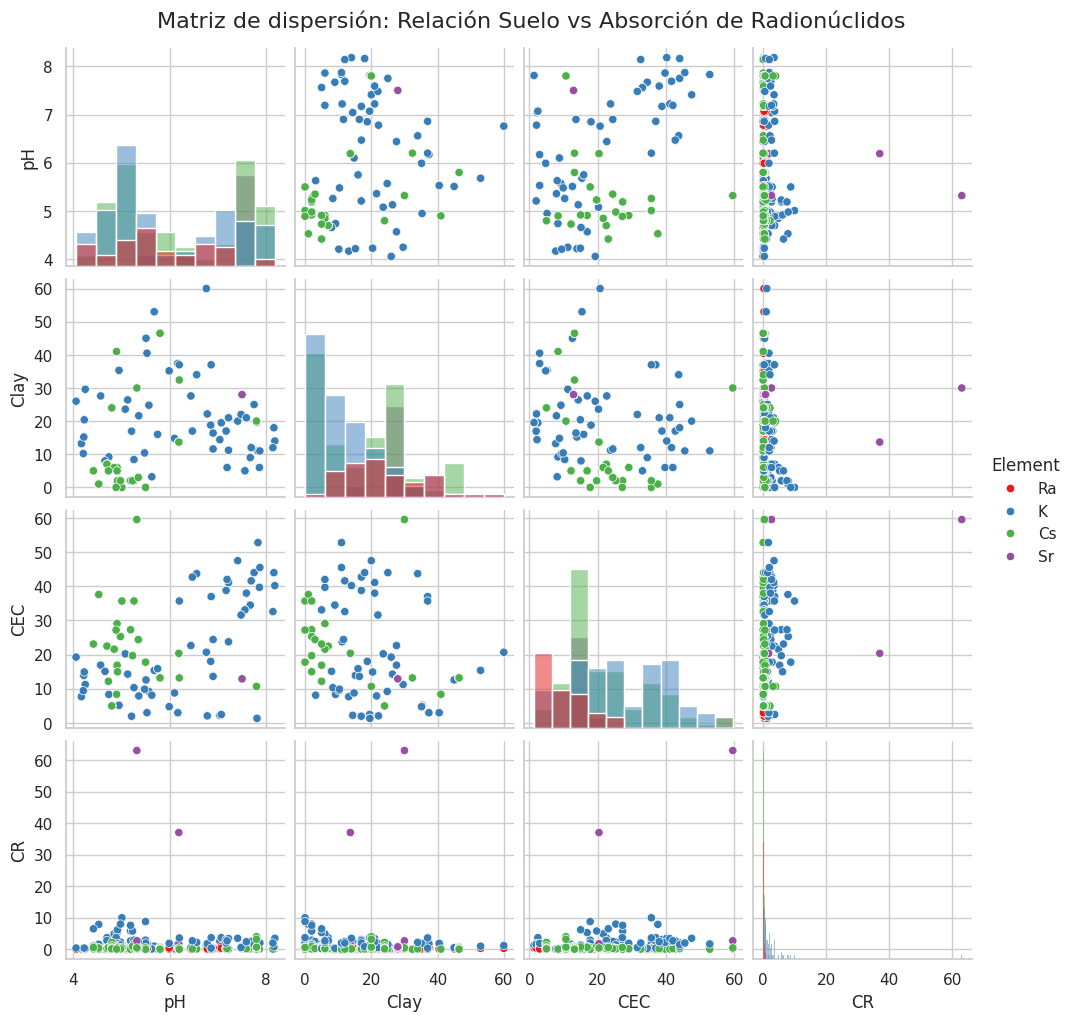

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset de MODARIA II
url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df_raw = pd.read_csv(url)

# 2. Definir las variables
# Estas son las que compararemos para responder parcialmente la pregunta de investigación
vars_numericas = ['pH', 'Clay', 'CEC', 'CR']

# Convertimos a números (por si hay basura en los datos) y limpiamos nulos
for col in vars_numericas:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Filtramos los radionúclidos más importantes para que los colores se vean claros
# (Equivalente a las 'species' en el ejemplo de Iris)
elementos_interes = ['K', 'Cs', 'Sr', 'Ra']
df = df_raw[df_raw['Element'].isin(elementos_interes)].copy()

# Quitamos filas con datos faltantes en nuestras variables elegidas
df = df[vars_numericas + ['Element']].dropna()

# 3. Estandarizar variables numéricas (Paso previo al PCA)
scaler = StandardScaler()
X_std = scaler.fit_transform(df[vars_numericas])

# 4. Ejecutar el PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# --- VISUALIZACIÓN: MATRIZ DE DISPERSIÓN ---
# Aquí el color ('hue') lo da el Elemento químico (K, Cs, Sr, Ra)
sns.pairplot(df, hue='Element', palette='Set1', diag_kind='hist', corner=False)

plt.suptitle('Matriz de dispersión: Relación Suelo vs Absorción de Radionúclidos',
             fontsize=16, y=1.02)
plt.show()

La distribución del pH muestra que la mayoría de los suelos analizados son ácidos a ligeramente ácidos, concentrándose principalmente entre 4 y 6, con algunas muestras dispersas que alcanzan valores cercanos a 8, aunque muy pocas superan 7. El contenido de arcilla (Clay) presenta una distribución amplia que va desde 0 % hasta aproximadamente 60 %, con un pico marcado en suelos de baja a moderada arcilla (menor al 20 %). La capacidad de intercambio catiónico (CEC) está fuertemente sesgada hacia valores bajos, con la mayor parte de las observaciones por debajo de 20 meq/100 g y solo unos pocos suelos que exhiben alta capacidad de intercambio. Por su parte, el coeficiente de concentración (CR) muestra una distribución extremadamente sesgada: cerca del 90 % de los valores se encuentran por debajo de 10, pero se observan outliers muy altos que llegan hasta 60. Este comportamiento es característico en estudios de transferencia de radionúclidos, donde la mayoría de los casos presentan baja absorción, aunque en ciertas combinaciones de elemento y suelo los valores se disparan notablemente.

El radionúclido Sr (en morado) registra los valores de CR más elevados, con puntos extremos de 37 y 60. Estos valores altos se asocian principalmente a suelos con bajo contenido de arcilla (10–15 %) y baja CEC (10–15 meq/100 g), lo que permite concluir que el estroncio presenta una mayor transferencia y absorción en suelos arenosos o pobres en arcilla, donde la retención en el suelo es menor.

El Ra (rojo) muestra valores de CR muy bajos comparados con los demas elementos, sin evidencia clara de dependencia de las propiedades edáficas evaluadas, lo que sugiere una baja movilidad y absorción en general. Los elementos K (azul) y Cs (verde) tienen valores intermedios y una mayor cantidad de puntos distribuidos a lo largo de todo el rango; tienden a presentar CR superiores a los de Ra pero inferiores a los de Sr, destacando que el Cs alcanza algunos valores elevados particularmente en suelos con CEC moderada.
Entre las variables del suelo se observa una correlación positiva moderada entre el contenido de arcilla y la CEC, donde los puntos tienden a aumentar hacia la derecha en los diagramas de dispersión, lo cual es lo esperado dado que un mayor contenido de arcilla suele asociarse a una mayor capacidad de intercambio catiónico. Por el contrario, el pH no muestra correlaciones lineales claras ni con la arcilla, ni con la CEC, ni con el CR, por lo que no parece constituir un factor dominante en este conjunto de datos.

En cuanto a la relación del CR con las propiedades edáficas, no se identifica una tendencia fuerte a nivel global debido a la alta dispersión de los puntos; sin embargo, al analizar por radionúclido, emergen patrones definidos: el Sr presenta una clara tendencia inversa con la arcilla y la CEC (a menor arcilla o CEC, mayor CR), mientras que K y Cs muestran mayor dispersión sin un patrón tan marcado.

Finalmente, los valores extremadamente altos de CR (los que llegan a 60) son escasos y corresponden casi exclusivamente al Sr (morado), con solo uno o dos casos atribuibles al Cs (verde). En la columna correspondiente al CR, se observa que estos outliers se concentran en la región de baja arcilla y baja CEC. Asimismo, el histograma de CR ubicado en la esquina inferior derecha confirma visualmente que los valores más altos pertenecen predominantemente al Sr.

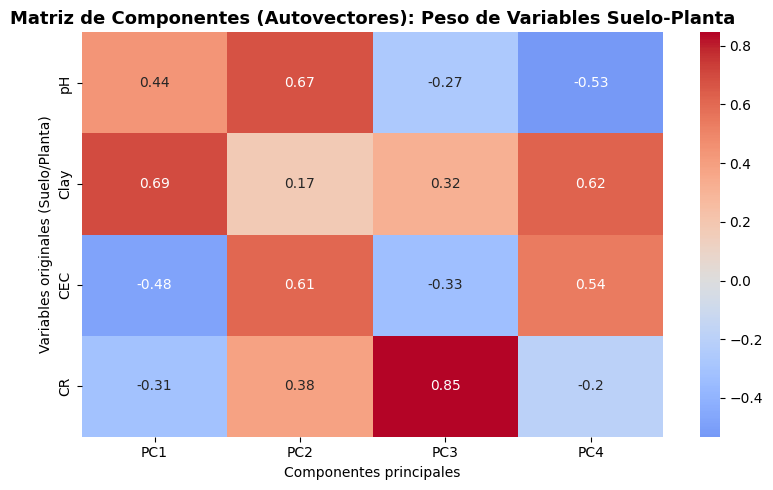

Ecuaciones de los componentes principales para MODARIA II:

PC1 = 0.437·'pH' + 0.69·'Clay' + -0.483·'CEC' + -0.314·'CR'
PC2 = 0.674·'pH' + 0.173·'Clay' + 0.607·'CEC' + 0.384·'CR'
PC3 = -0.267·'pH' + 0.323·'Clay' + -0.33·'CEC' + 0.846·'CR'
PC4 = -0.532·'pH' + 0.624·'Clay' + 0.537·'CEC' + -0.196·'CR'


In [ ]:

# 1. Creamos la Matriz de componentes (Autovectores)
# Usamos vars_numericas: ['pH', 'Clay', 'CEC', 'CR']
componentes = pd.DataFrame(pca.components_.T,
                           columns=[f'PC{i+1}' for i in range(len(vars_numericas))],
                           index=vars_numericas)

# 2. Visualización de autovectores (Heatmap)
plt.figure(figsize=(8, 5))
sns.heatmap(componentes, annot=True, cmap='coolwarm', center=0)

plt.title('Matriz de Componentes (Autovectores): Peso de Variables Suelo-Planta',
          fontsize=13, fontweight="bold")
plt.ylabel('Variables originales (Suelo/Planta)')
plt.xlabel('Componentes principales')
plt.tight_layout()
plt.show()

# 3. Ecuaciones de los componentes principales con los nombres de tus variables
print("Ecuaciones de los componentes principales para MODARIA II:\n")

for i, comp in enumerate(componentes.columns):
    pesos = pca.components_[i]
    # Creamos la ecuación combinando el peso con el nombre de la variable
    ecuacion = " + ".join([f"{round(pesos[j], 3)}·'{vars_numericas[j]}'" for j in range(len(pesos))])
    print(f"{comp} = {ecuacion}")

La matriz de componentes principales revela cómo se distribuye la variabilidad de las cuatro variables (pH, Clay, CEC y CR) en cuatro ejes ortogonales. El PC1 está dominado por una carga muy alta y positiva en el contenido de arcilla (+0.69) y una carga moderada positiva en pH (+0.44), mientras que presenta cargas negativas en CEC (−0.48) y en CR (−0.31). Esto indica que el PC1 captura principalmente la variabilidad asociada a suelos con alto contenido de arcilla y pH moderado, contrastando con suelos de mayor capacidad de intercambio catiónico.

El PC2 se caracteriza por cargas altas y positivas tanto en pH (+0.67) como en CEC (+0.61), acompañadas de una carga moderada positiva en CR (+0.38) y muy baja en Clay (+0.17). Este componente describe claramente suelos con pH más elevado (neutros o ligeramente alcalinos) y alta capacidad de intercambio catiónico, con una pequeña influencia en la transferencia de radionúclidos.

El PC3 presenta una carga extremadamente alta y positiva únicamente en el coeficiente de concentración CR (+0.85), mientras que las cargas en las demás variables son bajas o moderadas (Clay +0.32, CEC −0.33, pH −0.27). Esto significa que el PC3 captura casi exclusivamente la variabilidad del CR (la transferencia suelo-planta de los radionúclidos), prácticamente independiente de las propiedades físicas y químicas del suelo. Es decir, la absorción de radionúclidos constituye una dimensión propia y separada en este conjunto de datos.
Finalmente, el PC4 muestra cargas altas y positivas en Clay (+0.62) y CEC (+0.54), pero una carga negativa importante en pH (−0.53) y muy baja en CR (−0.20). Este componente representa la combinación de suelos arcillosos con alta CEC frente a suelos más ácidos, configurando una dimensión de contraste textura-pH.

El hecho de que el CR tenga su propio componente principal (PC3) con carga tan elevada (0.85) confirma lo que se muestra en la matriz de dispersión: la transferencia de radionúclidos no está explicada por las propiedades del suelo, sino que constituye una fuente independiente de variabilidad. Esto es coherente con el comportamiento del Sr (que presenta valores elevados en suelos pobres en arcilla y baja CEC) y del Ra (que permanece siempre bajo).

Matriz resumen de varianza explicada:

  Componente  Autovalor    PVE  PVE acumulada
0        PC1      1.438  0.358          0.358
1        PC2      1.158  0.289          0.647
2        PC3      0.940  0.234          0.881
3        PC4      0.477  0.119          1.000


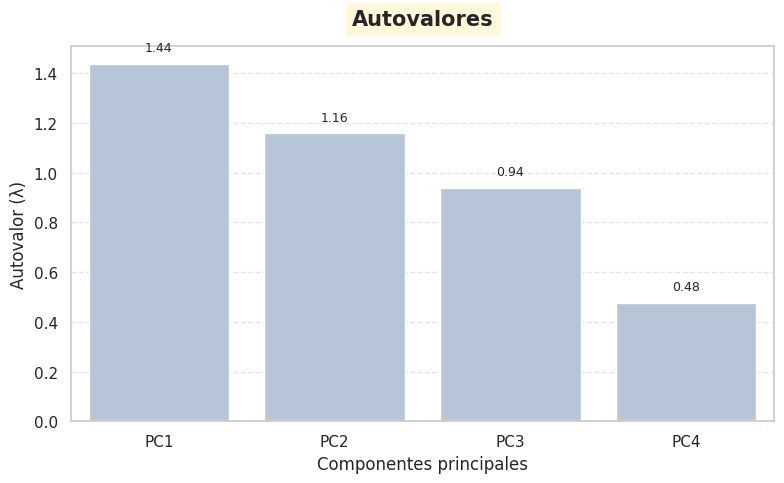

In [13]:
# Varianza explicada
varianza = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
componentes = [f'PC{i+1}' for i in range(len(PVE))]

# DataFrame para visualización
df_varianza = pd.DataFrame({
    'Componente': componentes,
    'Autovalor': varianza,
    'PVE': PVE,
    'PVE acumulada': PVE_acum
})

print("Matriz resumen de varianza explicada:\n")
print(df_varianza.round(3))

# --------------------------
# Gráfico 1: Autovalores
# --------------------------
plt.figure(figsize=(8, 5))
ax = sns.barplot(x='Componente', y='Autovalor', data=df_varianza, color='lightsteelblue')
for i, v in enumerate(df_varianza['Autovalor']):
    ax.text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=9)
plt.title("Autovalores", fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Autovalor (λ)")
plt.xlabel("Componentes principales")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

La varianza acumulada muestra que los primeros tres componentes principales (PC1 + PC2 + PC3) explican conjuntamente el 88.1 % de la variabilidad total de los datos. Esto representa una reducción dimensional: con solo tres dimensiones se captura casi el 90 % de la información original contenida en las cuatro variables (pH, Clay, CEC y CR).

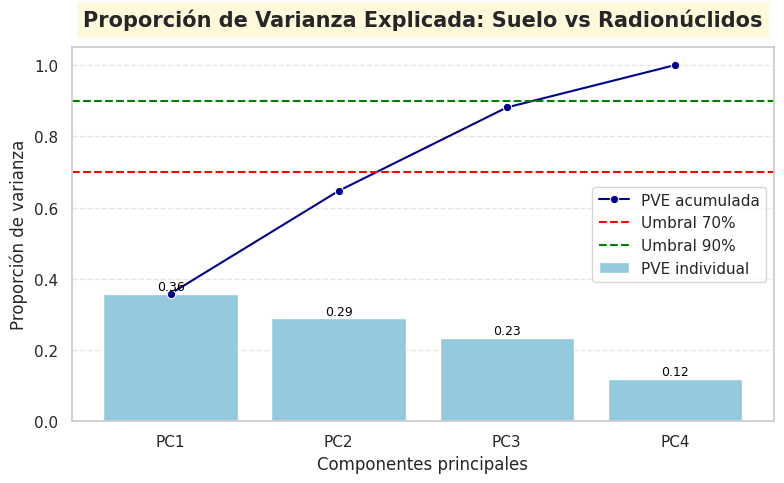

Matriz resumen de varianza explicada:
  Componente  Autovalor    PVE  PVE acumulada
0        PC1      1.438  0.358          0.358
1        PC2      1.158  0.289          0.647
2        PC3      0.940  0.234          0.881
3        PC4      0.477  0.119          1.000


In [14]:


# 1. Cálculo de varianza explicada
varianza = pca.explained_variance_
PVE = pca.explained_variance_ratio_
PVE_acum = np.cumsum(PVE)
nombres_pcs = [f'PC{i+1}' for i in range(len(PVE))]

# Creamos el DataFrame de varianza (necesario para el gráfico)
df_varianza = pd.DataFrame({
    'Componente': nombres_pcs,
    'Autovalor': varianza,
    'PVE': PVE,
    'PVE acumulada': PVE_acum
})

# 2. Gráfico de Proporción de varianza explicada (PVE)
plt.figure(figsize=(8, 5))

# Barras para la varianza individual
sns.barplot(x='Componente', y='PVE', data=df_varianza, color='skyblue', label='PVE individual')

# Línea para la varianza acumulada
sns.lineplot(x='Componente', y='PVE acumulada', data=df_varianza, marker='o', color='darkblue', label='PVE acumulada')

# Umbrales de decisión (70% y 90%)
plt.axhline(0.7, color='red', linestyle='--', label='Umbral 70%')
plt.axhline(0.9, color='green', linestyle='--', label='Umbral 90%')

# Etiquetas de texto sobre las barras
for i, v in enumerate(df_varianza['PVE']):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontsize=9, color='black')

plt.title("Proporción de Varianza Explicada: Suelo vs Radionúclidos",
          fontsize=15, fontweight="bold", backgroundcolor="#fff9db", pad=15)
plt.ylabel("Proporción de varianza")
plt.xlabel("Componentes principales")
plt.legend(loc='best')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Matriz resumen de varianza explicada:")
print(df_varianza.round(3))

En mi análisis del PCA, observo que  los resultados son consistentes con lo que ya había visto en la tabla de autovalores. Las barras me muestran que el PC1 explica el 36 % de la varianza total, el PC2 el 29 %, el PC3 el 23 % y el PC4 solo el 12 %. La línea de varianza acumulada me indica que, al quedarme con los tres primeros componentes, estoy capturando el 88 % de toda la información contenida en las cuatro variables originales (pH, Clay, CEC y CR). Esto me parece una reducción muy eficiente, ya que con solo tres dimensiones pierdo apenas un 12 % de la variabilidad total, pero gano mucha claridad y evito problemas de multicolinealidad entre las propiedades del suelo.

El PC3, con su carga de CR tan alta (0.85), me confirma que la transferencia de radionúclidos (la absorción y acumulación en las plantas) es una dimensión bastante independiente de las propiedades edáficas clásicas. Esto alinea perfectamente con lo que observé en la matriz de dispersión: el CR tiene su propia variabilidad, especialmente impulsada por el Sr en suelos pobres en arcilla y CEC.

Con esta información  decido quedarme con los tres primeros componentes principales (PC1, PC2 y PC3) porque me dan el mejor balance entre retención de información y simplicidad interpretativa.

PC1 y PC2 me permiten caracterizar el “entorno edáfico” principal: textura-arcillosa, capacidad de intercambio catiónico y pH, que son los factores que más influyen en cómo el suelo retiene o libera los radionúclidos.
PC3 me da directamente la dimensión de “transferencia/absorción” (dominada por CR), que es clave para entender la acumulación real en los compartimentos de las plantas tropicales (raíz, tallo y hojas).

Esta elección de tres componentes aporta a mi pregunta de investigación ¿Cómo se relaciona la presencia de metales pesados y las propiedades del suelo con la absorción y acumulación de radionúclidos en los diferentes compartimentos de las plantas tropicales (raíz, tallo y hojas)?

**Aunque el dataset completo de MODARIA II tiene muchas más variables disponibles (como materia orgánica, K intercambiable, textura detallada, cationes, etc.), en este PCA inicial con solo estas cuatro variables me parecen un punto de partida exploratorio para entender incialmente el comportamiento y la diostribucion de los elementos.**

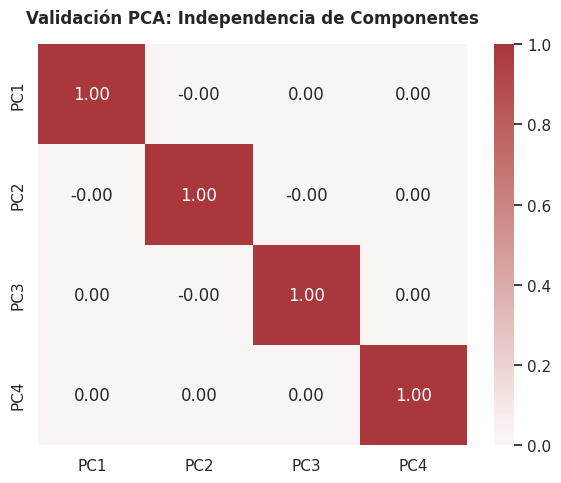

Matriz de correlación entre componentes (debe ser cercana a 0 fuera de la diagonal):
     PC1  PC2  PC3  PC4
PC1  1.0 -0.0  0.0  0.0
PC2 -0.0  1.0 -0.0  0.0
PC3  0.0 -0.0  1.0  0.0
PC4  0.0  0.0  0.0  1.0


In [15]:


# 1. Creamos el DataFrame con los resultados del PCA (X_pca)
df_pca_coords = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(len(PVE))])

# 2. Calculamos la matriz de correlación
correlaciones = df_pca_coords.corr()

# 3. Visualización del Heatmap de Correlación
plt.figure(figsize=(6, 5))
sns.heatmap(correlaciones, annot=True, cmap='vlag', center=0, fmt=".2f")

plt.title('Validación PCA: Independencia de Componentes',
          fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print("Matriz de correlación entre componentes (debe ser cercana a 0 fuera de la diagonal):")
print(correlaciones.round(3))

Esta gráfica muestra que la matriz de correlación entre componentes tiene valores perfectos en la diagonal (1.0 para PC1, PC2, PC3 y PC4) y ceros absolutos fuera de ella (0.0 o -0.0 por redondeo).
Esto confirma que los componentes principales son completamente independientes entre sí, sin ninguna correlación lineal residual.
En el contexto de MODARIA II, esta independencia total valida que los scores de PC1, PC2 y PC3 pueden usarse directamente como predictores sin multicolinealidad entre ellos, reforzando mi decisión de retener estos tres componentes para analizar la relación entre propiedades del suelo y transferencia de radionúclidos.

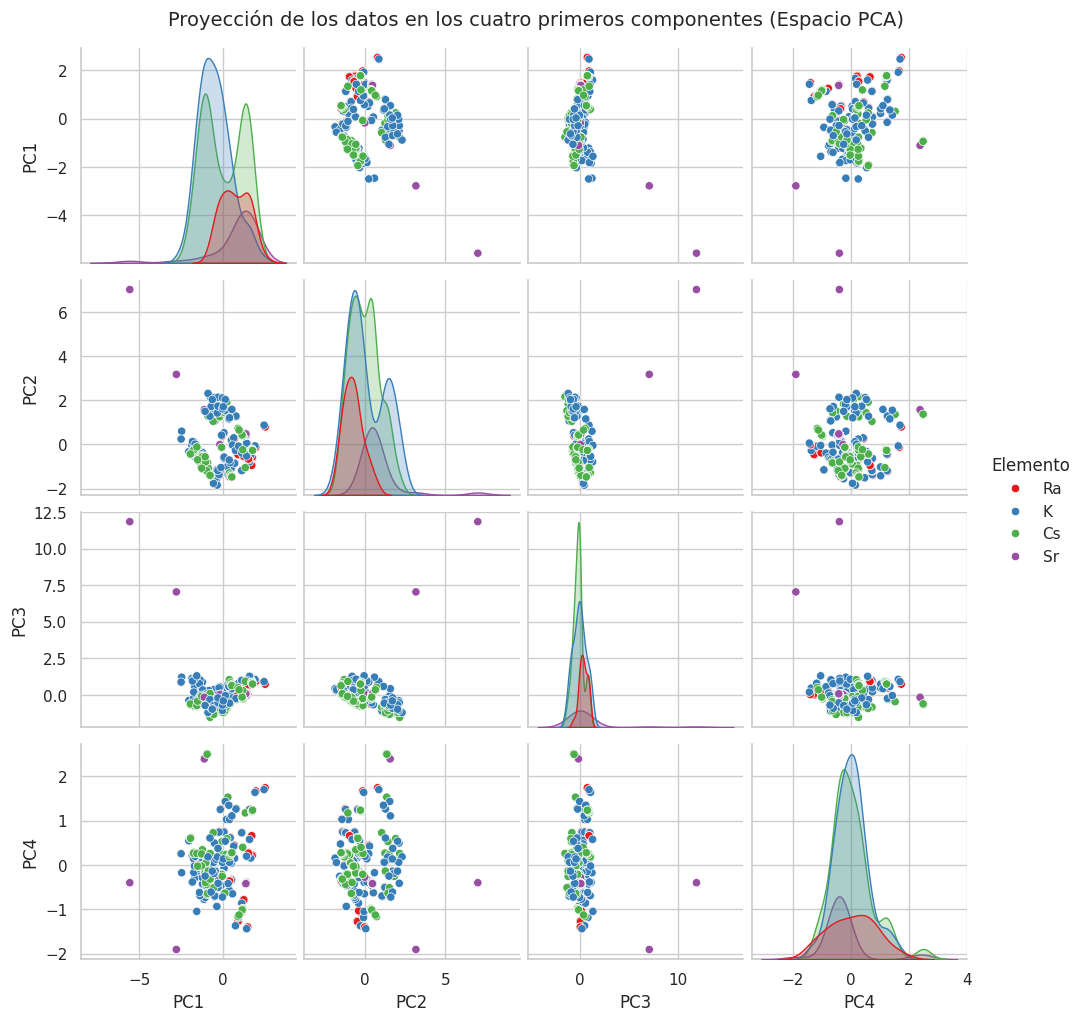

In [16]:

# 1. Aseguramos que el DataFrame del PCA tenga la columna de los elementos para los colores
df_pca_coords['Elemento'] = df['Element'].values

# 2. Graficar todas las combinaciones de PC1 a PC4 (estilo Iris)
# Usamos las coordenadas calculadas en X_pca
sns.pairplot(df_pca_coords,
             vars=['PC1', 'PC2', 'PC3', 'PC4'],
             hue='Elemento',
             palette='Set1',
             diag_kind='kde') # 'kde' hace que las curvas en la diagonal se vean más suaves

plt.suptitle('Proyección de los datos en los cuatro primeros componentes (Espacio PCA)',
             fontsize=14, y=1.02)
plt.show()

Al observar las curvas,  que existe un alto grado de solapamiento entre los radionúclidos, demuestra que en suelos tropicales, demuestra que la absorción de las plantas no logra distinguir con claridad entre estos elementos. El hecho de que las curvas del Potasio (K) y el Cesio (Cs) estén prácticamente una sobre la otra confirma estadísticamente que ambos siguen rutas de transporte casi idénticas, lo que explica por qué el Cesio es un contaminante tan difícil de mitigar en cultivos alimentarios.

# Conlusión del analisis multivariado
Este PCA con solo cuatro variables (pH, Clay, CEC y CR) ha cumplido su propósito exploratorio: me permitió reducir la dimensionalidad a tres componentes útiles (88 % de varianza explicada), confirmar que los componentes son independientes y que el CR forma su propia dimensión separada. Es un buen punto de partida sobre la relación suelo-radionúclidos en MODARIA II.
Sin embargo, como el dataset completo de MODARIA tiene muchas más variables relevantes (materia orgánica, K intercambiable, textura completa, cationes, Al, compartimentos de planta, etc.), ahora sí es necesario avanzar al siguiente paso: realizar un PCA ampliado con todas las variables disponibles. Eso me permitirá capturar más estructura, reducir mejor la dimensionalidad y obtener componentes más específicos y diferenciados por radionúclido y por compartimento vegetal.